In [1]:
import os

os.chdir("/home/jovyan/work")  # Move to climate-research-workbench root
print(f"CWD: {os.getcwd()}")

CWD: /home/jovyan/work


In [2]:
!pip install -q kornia

In [3]:
# ==========================================
# 🗂  Unique Run Folder Setup
# Every run creates: runs/YYYYMMDD_HHMMSS_leadNd/
#   config.json                    — all hyper-parameters
#   runtime.log                    — epoch logs + timing
#   chart_*_config.json            — per-chart render config
#   srunet_training_curves.png     — loss/RMSE charts
#   srunet_eval_<date>.png         — spatial eval chart
#   metrics.csv                    — final test metrics
# ==========================================
import os
import json as _json
import datetime as _dt

_run_start = _dt.datetime.now()
_run_id    = _run_start.strftime('%Y%m%d_%H%M%S')

# Temporary placeholder; RUN_DIR is refreshed once lead_days is known (Config cell)
RUN_DIR   = os.path.join('runs', f'{_run_id}_lead1d')
os.makedirs(RUN_DIR, exist_ok=True)
print(f'Run folder (placeholder): {RUN_DIR}')

# ── Runtime log helper ──────────────────────────────────────────────────
_LOG_PATH = os.path.join(RUN_DIR, 'runtime.log')

VAR_LABELS = ["U10 (m/s)", "V10 (m/s)", "T2m (K)", "TP 24hr (mm)"]

def _log(msg: str):
    ts   = _dt.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    line = f'[{ts}] {msg}'
    print(line)
    with open(_LOG_PATH, 'a') as _f:
        _f.write(line + '\n')

_log(f'=== Run started  (id={_run_id}) ===')
_log(f'Run dir: {RUN_DIR}')

# ── Chart-save helper ───────────────────────────────────────────────────
def save_fig(fig, name: str, dpi: int = 150):
    path = os.path.join(RUN_DIR, name)
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    _log(f'Chart saved → {path}')
    return path


Run folder (placeholder): runs/20260506_013434_lead1d
[2026-05-06 01:34:34] === Run started  (id=20260506_013434) ===
[2026-05-06 01:34:34] Run dir: runs/20260506_013434_lead1d


## Import Library

In [4]:
import datetime
import xesmf as xe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch.nn.functional as F
import kornia

In [5]:
## Config
# Perfect Prognosis: X = low-res ERA5, Y = high-res ERA5
# No NWP model lead time — set lead_days = 0 to mark PP scenario
lead_days = 0
scale = 6
seed = 42
BATCH_SIZE = 32

# Date-based split boundaries (inclusive)
train_start_date = "2018-01-01"
train_end_date   = "2021-12-31"
val_start_date   = "2022-01-01"
val_end_date     = "2022-06-30"
test_start_date  = "2022-07-01"
test_end_date    = "2022-12-31"

# ── Refresh RUN_DIR now that lead_days is defined ──────────────────────
RUN_DIR = os.path.join('runs', f'{_run_id}')
os.makedirs(RUN_DIR, exist_ok=True)
_LOG_PATH = os.path.join(RUN_DIR, 'runtime.log')
print(f'Run folder: {RUN_DIR}')

VAR_LABELS_VIZ = ["U10 (m/s)", "V10 (m/s)", "T2m (K)", "TP 24hr (mm)"]
target_date = np.datetime64("2022-08-01")

# ── Persist config ──────────────────────────────────────────────────────
_config = {
    'scenario'         : 'scenario2-gan-mae-perfect-prognosis',
    'lead_days'        : lead_days,
    'run_id'           : _run_id,
    'run_dir'          : RUN_DIR,
    'scale'            : scale,
    'seed'             : seed,
    'BATCH_SIZE'       : BATCH_SIZE,
    'train_start_date' : train_start_date,
    'train_end_date'   : train_end_date,
    'val_start_date'   : val_start_date,
    'val_end_date'     : val_end_date,
    'test_start_date'  : test_start_date,
    'test_end_date'    : test_end_date,
    'started_at'       : _run_start.isoformat(),
}
_cfg_path = os.path.join(RUN_DIR, 'config.json')
with open(_cfg_path, 'w') as _f:
    _json.dump(_config, _f, indent=2)
_log(f'Config saved → {_cfg_path}')

Run folder: runs/20260506_013434
[2026-05-06 01:34:37] Config saved → runs/20260506_013434/config.json


In [6]:
# Reproducibility
import random

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(seed)

## Load Datasets

In [7]:
ds_hr = xr.open_dataset("data/era5_indonesia_2018-2022.zarr")

## Cropping data to this dimension
- Low-res shape  : 24 32
- High-res shape : 144 192

In [8]:
import numpy as np
import xarray as xr
import xesmf as xe

# =========================================
# Truth is the constraint — build LR from HR truth
# =========================================
scale = 6

ds_hr = ds_hr.sortby("latitude")  # ensure south → north

tr_lons = ds_hr.longitude.values
tr_lats = ds_hr.latitude.values

# Pseudo-forecast grid from truth stride (Perfect Prognosis setup)
fc_lons = tr_lons[::scale]
fc_lats = tr_lats[::scale]

# ── Force start like forecast-correction notebook ──
lon_start = 90.0
lat_start = -13.5

# Snap to available pseudo-forecast coords
lon_start = float(fc_lons[np.argmin(np.abs(fc_lons - lon_start))])
lat_start = float(fc_lats[np.argmin(np.abs(fc_lats - lat_start))])

# ── Snap to truth grid indices ──
lon_start_idx = np.argmin(np.abs(tr_lons - lon_start))
lat_start_idx = np.argmin(np.abs(tr_lats - lat_start))

print(f"lon_start={lon_start}, idx={lon_start_idx}, truth={tr_lons[lon_start_idx]}")
print(f"lat_start={lat_start}, idx={lat_start_idx}, truth={tr_lats[lat_start_idx]}")

# ── Available truth points from start ──
avail_lon = len(tr_lons) - lon_start_idx
avail_lat = len(tr_lats) - lat_start_idx

# ── Max LR points truth can support ──
max_fc_lon = avail_lon // scale
max_fc_lat = avail_lat // scale

# ── Clamp to U-Net friendly size (24×32) ──
max_fc_lon = min(max_fc_lon, 32)
max_fc_lat = min(max_fc_lat, 24)

# ── Slice truth by exact count (HR target) ──
ds_tr = ds_hr.isel(
    longitude=slice(lon_start_idx, lon_start_idx + max_fc_lon * scale),
    latitude=slice(lat_start_idx, lat_start_idx + max_fc_lat * scale),
)
HIGH_LON = len(ds_tr.longitude)
HIGH_LAT = len(ds_tr.latitude)

# ── Build LR grid from HR stride ──
lr_lons = ds_tr.longitude.values[::scale]
lr_lats = ds_tr.latitude.values[::scale]

ds_lr_grid = xr.Dataset(
    coords={
        "lat": ("lat", lr_lats),
        "lon": ("lon", lr_lons),
    }
)

# ── Regrid HR -> LR with xESMF ──
ds_hr_in = ds_tr.rename({"latitude": "lat", "longitude": "lon"})
regridder_hr2lr = xe.Regridder(
    ds_hr_in,
    ds_lr_grid,
    method="bilinear",
    periodic=False,
    reuse_weights=False,
    ignore_degenerate=True,
)
ds_lr = regridder_hr2lr(ds_hr_in, keep_attrs=True).rename({"lat": "latitude", "lon": "longitude"})

LOW_LON = len(ds_lr.longitude)
LOW_LAT = len(ds_lr.latitude)

print(f"\nLow Resolution domain : lon {ds_lr.longitude.values[0]:.2f}→{ds_lr.longitude.values[-1]:.2f}"
      f"  lat {ds_lr.latitude.values[0]:.2f}→{ds_lr.latitude.values[-1]:.2f}")
print(f"high resolution domain    : lon {ds_tr.longitude.values[0]:.2f}→{ds_tr.longitude.values[-1]:.2f}"
      f"  lat {ds_tr.latitude.values[0]:.2f}→{ds_tr.latitude.values[-1]:.2f}")
print(f"\nFinal low resolution grid : {LOW_LAT} lat × {LOW_LON} lon")
print(f"Final truth grid    : {HIGH_LAT} lat × {HIGH_LON} lon")
print(f"Scale lon           : {HIGH_LON / LOW_LON:.6f}")
print(f"Scale lat           : {HIGH_LAT / LOW_LAT:.6f}")

lon_ok = np.allclose(ds_tr.longitude.values[::scale], ds_lr.longitude.values, atol=1e-8)
lat_ok = np.allclose(ds_tr.latitude.values[::scale],  ds_lr.latitude.values,  atol=1e-8)
assert lon_ok and lat_ok, "LR grid does not align with HR stride — check scale factor!"
print(f"Grid alignment check passed (lon_ok={lon_ok}, lat_ok={lat_ok})")

# ── Perfect Prognosis aliases ────────────────────────────────────────────
# Scenario 2 is Perfect Prognosis: the "forecast" input (X) is ERA5 itself
# degraded to low resolution.  There is no separate NWP model output.
#   ds_fc         → low-res ERA5  (predictor / pseudo-forecast, 24×32)
#   ds_tr_aligned → high-res ERA5 truth, cropped to the same domain (144×192)
ds_fc         = ds_lr   # alias — used throughout downstream cells
ds_tr_aligned = ds_tr   # alias — used throughout downstream cells
print("Perfect Prognosis aliases set:")
print(f"  ds_fc         = ds_lr  ({LOW_LAT}×{LOW_LON})")
print(f"  ds_tr_aligned = ds_tr  ({HIGH_LAT}×{HIGH_LON})")


lon_start=90.0, idx=0, truth=90.0
lat_start=-13.5, idx=6, truth=-13.5

Low Resolution domain : lon 90.00→136.50  lat -13.50→21.00
high resolution domain    : lon 90.00→137.75  lat -13.50→22.25

Final low resolution grid : 24 lat × 32 lon
Final truth grid    : 144 lat × 192 lon
Scale lon           : 6.000000
Scale lat           : 6.000000
Grid alignment check passed (lon_ok=True, lat_ok=True)
Perfect Prognosis aliases set:
  ds_fc         = ds_lr  (24×32)
  ds_tr_aligned = ds_tr  (144×192)


## Check Missing Value

In [9]:
import numpy as np

def check_nan_summary(ds, name):
    print(f"\n==== {name} ====")
    for var in ds.data_vars:
        data = ds[var].values
        total = data.size
        n_nan = np.isnan(data).sum()
        pct = (n_nan / total) * 100
        print(f"{var:30s} | NaNs: {n_nan:10d} | {pct:.5f}%")

# check_nan_summary(ds_lr, "Low-res")
# check_nan_summary(ds_hr, "Truth (High-res)")

## Data model preparation

In [10]:
# ==========================================
# 1️⃣ Variable stacking
# ==========================================
VARS = [
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "2m_temperature",
    "total_precipitation_24hr",
]
TP_IDX = VARS.index("total_precipitation_24hr")  # index 3

# Stack forecast (low-res): (time, channel, lat, lon)
X = np.stack(
    [ds_lr[v].values for v in VARS],
    axis=1
).astype(np.float32)

# Stack truth (high-res): (time, channel, lat, lon)
Y = np.stack(
    [ds_tr[v].values for v in VARS],
    axis=1
).astype(np.float32)

# ── Fill NaNs in forecast (X) before any processing ──────────────
# X has ~0.027 % NaN values (confirmed in missing-value check above).
# Strategy: per-channel spatial mean imputation — fast and unbiased.
for _c in range(X.shape[1]):
    _ch   = X[:, _c, :, :]                          # (N, H, W)
    _mask = np.isnan(_ch)
    if _mask.any():
        _fill = np.nanmean(_ch)                     # scalar fallback
        _ch[_mask] = _fill
        X[:, _c, :, :] = _ch
        print(f"  X channel {_c}: filled {_mask.sum()} NaNs with mean={_fill:.4f}")
assert not np.isnan(X).any(), "X still contains NaNs after imputation!"

# ── Fill NaNs in truth (Y) ───────────────────────────────────────────
for _c in range(Y.shape[1]):
    _ch   = Y[:, _c, :, :]
    _mask = np.isnan(_ch)
    if _mask.any():
        _fill = np.nanmean(_ch)
        _ch[_mask] = _fill
        Y[:, _c, :, :] = _ch
        print(f"  Y channel {_c}: filled {_mask.sum()} NaNs with mean={_fill:.4f}")
assert not np.isnan(Y).any(), "Y still contains NaNs after imputation!"
print("X NaN fill complete — no NaNs remain.")

print("Before axis check:")
print("X shape:", X.shape)  # (N, 4, 24, 32)
print("Y shape:", Y.shape)  # (N, 4, 144, 192)

# ==========================================
# 2️⃣ Axis fix (if lat/lon reversed in Y)
# ==========================================
expected_h = X.shape[2] * 6  # 144
expected_w = X.shape[3] * 6  # 192

if Y.shape[2] == expected_w and Y.shape[3] == expected_h:
    Y = np.transpose(Y, (0, 1, 3, 2))
    print("Y axes corrected")

print("Corrected shapes:")
print("X:", X.shape)
print("Y:", Y.shape)

# ==========================================
# 2.5 Log-transform precipitation BEFORE normalisation
# ==========================================
# Precipitation is non-negative & heavily right-skewed; log1p handles zeros safely
print(f"\nBefore log1p — X TP min/max: {X[:, TP_IDX].min():.4f} / {X[:, TP_IDX].max():.4f}")
print(f"Before log1p — Y TP min/max: {Y[:, TP_IDX].min():.4f} / {Y[:, TP_IDX].max():.4f}")

X[:, TP_IDX] = np.log1p(np.clip(X[:, TP_IDX], 0, None))
Y[:, TP_IDX] = np.log1p(np.clip(Y[:, TP_IDX], 0, None))

print(f"After  log1p — X TP min/max: {X[:, TP_IDX].min():.4f} / {X[:, TP_IDX].max():.4f}")
print(f"After  log1p — Y TP min/max: {Y[:, TP_IDX].min():.4f} / {Y[:, TP_IDX].max():.4f}")

# ==========================================
# 3️⃣ Train / Val / Test split (date-based)
#    Split BEFORE normalization!
#    Keep temporal order — no shuffle
# ==========================================
times = ds_lr.time.values  # Perfect Prognosis: use ds_lr (= ds_fc alias)
train_mask = (times >= np.datetime64(train_start_date)) & (times <= np.datetime64(train_end_date))
val_mask   = (times >= np.datetime64(val_start_date)) & (times <= np.datetime64(val_end_date))
test_mask  = (times >= np.datetime64(test_start_date)) & (times <= np.datetime64(test_end_date))

assert train_mask.any(), "No samples found for train date range"
assert val_mask.any(), "No samples found for val date range"
assert test_mask.any(), "No samples found for test date range"

X_train = X[train_mask]
X_val   = X[val_mask]
X_test  = X[test_mask]

Y_train = Y[train_mask]
Y_val   = Y[val_mask]
Y_test  = Y[test_mask]

print("\nDate-based split sizes:")
print(f"  Train : {len(X_train)} ({str(times[train_mask][0])[:10]} → {str(times[train_mask][-1])[:10]})")
print(f"  Val   : {len(X_val)} ({str(times[val_mask][0])[:10]} → {str(times[val_mask][-1])[:10]})")
print(f"  Test  : {len(X_test)} ({str(times[test_mask][0])[:10]} → {str(times[test_mask][-1])[:10]})")

# ==========================================
# 4️⃣ Normalization — train stats only!
#    SEPARATE stats for X (low-res) and Y (high-res)
#    because they live on different grids
# ==========================================
# X stats: (1, C, 1, 1)
X_mean = X_train.mean(axis=(0, 2, 3), keepdims=True)
X_std  = X_train.std( axis=(0, 2, 3), keepdims=True)

# Y stats: (1, C, 1, 1)
Y_mean = Y_train.mean(axis=(0, 2, 3), keepdims=True)
Y_std  = Y_train.std( axis=(0, 2, 3), keepdims=True)

X_train = (X_train - X_mean) / (X_std + 1e-6)
X_val   = (X_val   - X_mean) / (X_std + 1e-6)
X_test  = (X_test  - X_mean) / (X_std + 1e-6)

Y_train = (Y_train - Y_mean) / (Y_std + 1e-6)
Y_val   = (Y_val   - Y_mean) / (Y_std + 1e-6)
Y_test  = (Y_test  - Y_mean) / (Y_std + 1e-6)

# Save stats for denormalization at inference
# NOTE: expm1() needed after denormalising the TP channel
norm_stats = {
    "X_mean": torch.tensor(X_mean, dtype=torch.float32),
    "X_std" : torch.tensor(X_std,  dtype=torch.float32),
    "Y_mean": torch.tensor(Y_mean, dtype=torch.float32),
    "Y_std" : torch.tensor(Y_std,  dtype=torch.float32),
    "variables": VARS,
    "tp_index": TP_IDX,
    "log1p_applied": True,
}
print("\nX norm stats per channel:")
for i, v in enumerate(VARS):
    print(f"  {v}: mean={X_mean[0,i,0,0]:.4f}, std={X_std[0,i,0,0]:.4f}")
print("Y norm stats per channel:")
for i, v in enumerate(VARS):
    print(f"  {v}: mean={Y_mean[0,i,0,0]:.4f}, std={Y_std[0,i,0,0]:.4f}")

# ==========================================
# 5️⃣ Convert to PyTorch tensors
# ==========================================
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val,   dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)

Y_train = torch.tensor(Y_train, dtype=torch.float32)
Y_val   = torch.tensor(Y_val,   dtype=torch.float32)
Y_test  = torch.tensor(Y_test,  dtype=torch.float32)

print("\nFinal tensor shapes:")
print(f"  X_train : {X_train.shape}")
print(f"  Y_train : {Y_train.shape}")
print(f"  X_val   : {X_val.shape}")
print(f"  Y_val   : {Y_val.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  Y_test  : {Y_test.shape}")

# ==========================================
# 6️⃣ DataLoaders
# ==========================================

train_loader = DataLoader(
    TensorDataset(X_train, Y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)
val_loader = DataLoader(
    TensorDataset(X_val, Y_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)
test_loader = DataLoader(
    TensorDataset(X_test, Y_test),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

print(f"\nDataLoaders ready:")
print(f"  Train batches : {len(train_loader)}")
print(f"  Val batches   : {len(val_loader)}")
print(f"  Test batches  : {len(test_loader)}")

# ==========================================
# 7️⃣ Denormalization helper (use at inference)
# ==========================================
def denormalize(tensor, mu, sig, tp_idx=TP_IDX):
    """Reverse z-score, then expm1 on the TP channel."""
    mu  = mu.to(tensor.device)
    sig = sig.to(tensor.device)
    out = tensor * (sig + 1e-6) + mu
    out[:, tp_idx] = torch.expm1(out[:, tp_idx])  # reverse log1p
    return out

X NaN fill complete — no NaNs remain.
Before axis check:
X shape: (7304, 4, 24, 32)
Y shape: (7304, 4, 144, 192)
Corrected shapes:
X: (7304, 4, 24, 32)
Y: (7304, 4, 144, 192)

Before log1p — X TP min/max: -0.0000 / 0.4984
Before log1p — Y TP min/max: -0.0000 / 0.6023
After  log1p — X TP min/max: 0.0000 / 0.4044
After  log1p — Y TP min/max: 0.0000 / 0.4715

Date-based split sizes:
  Train : 5841 (2018-01-01 → 2021-12-31)
  Val   : 721 (2022-01-01 → 2022-06-30)
  Test  : 733 (2022-07-01 → 2022-12-31)

X norm stats per channel:
  10m_u_component_of_wind: mean=-1.1941, std=4.1289
  10m_v_component_of_wind: mean=0.3375, std=3.4082
  2m_temperature: mean=300.0585, std=2.2168
  total_precipitation_24hr: mean=0.0060, std=0.0104
Y norm stats per channel:
  10m_u_component_of_wind: mean=-1.1902, std=4.0955
  10m_v_component_of_wind: mean=0.2801, std=3.3993
  2m_temperature: mean=300.0140, std=2.3289
  total_precipitation_24hr: mean=0.0061, std=0.0105

Final tensor shapes:
  X_train : torch.Size(

In [11]:
# ==========================================
# ==========================================
# GAN Architecture for Super-Resolution  
# Based on ESRGAN with RRDB blocks
# ==========================================
# ==========================================
# ==========================================
# GAN Architecture for Super-Resolution  
# Based on ESRGAN with RRDB blocks
# ==========================================

# ==========================================
# Dense Block (used in RRDB)
# ==========================================

class DenseLayer(nn.Module):
    """Single dense layer: Conv + ReLU"""
    def __init__(self, in_ch, growth_rate=32):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, growth_rate, kernel_size=3, padding=1, bias=True)
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, x):
        out = self.relu(self.conv(x))
        return torch.cat([x, out], dim=1)  # Concatenate input with output


class ResidualDenseBlock(nn.Module):
    """
    Residual Dense Block (RDB)
    Multiple dense layers with residual connection
    """
    def __init__(self, in_ch, growth_rate=32, num_layers=5):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(num_layers):
            self.layers.append(DenseLayer(in_ch + i * growth_rate, growth_rate))
        
        # Local fusion (1x1 conv to reduce channels back)
        self.local_fusion = nn.Conv2d(
            in_ch + num_layers * growth_rate,
            in_ch,
            kernel_size=1,
            bias=True
        )
        self.beta = 0.2  # Residual scaling factor
    
    def forward(self, x):
        identity = x
        for layer in self.layers:
            x = layer(x)
        x = self.local_fusion(x)
        return identity + self.beta * x


class RRDB(nn.Module):
    """
    Residual-in-Residual Dense Block
    Stack of multiple RDB blocks with residual connection
    """
    def __init__(self, in_ch, growth_rate=32, num_rdb=3):
        super().__init__()
        self.rdb_blocks = nn.ModuleList([
            ResidualDenseBlock(in_ch, growth_rate) for _ in range(num_rdb)
        ])
        self.beta = 0.2  # Residual scaling factor
    
    def forward(self, x):
        identity = x
        for rdb in self.rdb_blocks:
            x = rdb(x)
        return identity + self.beta * x


# ==========================================
# Generator Network (RRDB-based)
# ==========================================

class RRDBGenerator(nn.Module):
    """
    Generator with RRDB blocks for super-resolution
    Input  : (B, 4, 24, 32)   — low-res forecast  
    Output : (B, 4, 144, 192) — high-res prediction
    """
    def __init__(self, in_ch=4, out_ch=4, base_ch=64, num_rrdb=4, growth_rate=32):
        super().__init__()
        
        # Initial feature extraction
        self.conv_first = nn.Conv2d(in_ch, base_ch, kernel_size=3, padding=1, bias=True)
        
        # RRDB blocks
        self.rrdb_blocks = nn.ModuleList([
            RRDB(base_ch, growth_rate=growth_rate) for _ in range(num_rrdb)
        ])
        
        # Feature fusion after RRDB blocks
        self.conv_body = nn.Conv2d(base_ch, base_ch, kernel_size=3, padding=1, bias=True)
        
        # 6× Upsampling (via two 2× steps + one 3× step)
        # Step 1: 2× upscale  (24,32) → (48,64)
        self.up1 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(base_ch, base_ch, kernel_size=3, padding=1, bias=True),
            nn.ReLU(inplace=True)
        )
        
        # Step 2: 3× upscale (48,64) → (144,192)
        self.up2 = nn.Sequential(
            nn.Upsample(scale_factor=3, mode='bilinear', align_corners=False),
            nn.Conv2d(base_ch, base_ch, kernel_size=3, padding=1, bias=True),
            nn.ReLU(inplace=True)
        )
        
        # Final refinement
        self.conv_last = nn.Sequential(
            nn.Conv2d(base_ch, base_ch, kernel_size=3, padding=1, bias=True),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch, out_ch, kernel_size=3, padding=1, bias=True)
        )
    
    def forward(self, x):
        # Initial feature extraction
        feat_init = self.conv_first(x)  # (B, 64, 24, 32)
        
        # RRDB trunk
        feat = feat_init
        for rrdb in self.rrdb_blocks:
            feat = rrdb(feat)
        
        # Global residual learning
        feat = self.conv_body(feat)
        feat = feat + feat_init  # Long skip connection
        
        # 6× upsampling
        feat = self.up1(feat)  # (B, 64, 48, 64)
        feat = self.up2(feat)  # (B, 64, 144, 192)
        
        # Final output
        out = self.conv_last(feat)  # (B, 4, 144, 192)
        return out
        
class ResidualBlock(nn.Module):
    """
    Mirrors dl4ds ResidualBlock: Conv → Norm → Act → Conv → Norm + skip
    """
    def __init__(self, n_filters, normalization=None, activation='relu'):
        super().__init__()
        layers_1 = [nn.Conv2d(n_filters, n_filters, 3, padding=1, bias=(normalization is None))]
        if normalization == 'bn':
            layers_1.append(nn.BatchNorm2d(n_filters))
        elif normalization == 'ln':
            layers_1.append(nn.GroupNorm(1, n_filters))  # LayerNorm equivalent for 2D
        layers_1.append(nn.ReLU(inplace=True) if activation == 'relu' else nn.LeakyReLU(0.2, inplace=True))

        layers_2 = [nn.Conv2d(n_filters, n_filters, 3, padding=1, bias=(normalization is None))]
        if normalization == 'bn':
            layers_2.append(nn.BatchNorm2d(n_filters))
        elif normalization == 'ln':
            layers_2.append(nn.GroupNorm(1, n_filters))

        self.block1 = nn.Sequential(*layers_1)
        self.block2 = nn.Sequential(*layers_2)
        self.act_out = nn.ReLU(inplace=True) if activation == 'relu' else nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        identity = x
        out = self.block1(x)
        out = self.block2(out)
        return self.act_out(out + identity)


# ==========================================
# Conditional Discriminator — dl4ds style
# ==========================================

class ResidualDiscriminator(nn.Module):
    """
    Matches dl4ds residual_discriminator() structure:

    Branch 1 (LR input):
        Conv → n_res_blocks × ResidualBlock → Conv → Add(skip)

    Branch 2 (HR reference/generated):
        Conv → n_res_blocks × ResidualBlock → downsample to LR size

    Fusion:
        Concat → ResidualBlock → GlobalAvgPool → Dropout → Dense(32) → Dense(1)

    Args:
        in_ch_lr      : channels in LR input  (matches your in_ch_lr=4)
        in_ch_hr      : channels in HR input  (matches your in_ch_hr=4)
        lr_size       : (H, W) of LR grid, e.g. (24, 32) — used to downsample HR branch
        scale         : upsampling scale factor (e.g. 6)
        n_filters     : base filter count (dl4ds default: 8, feel free to use 64)
        n_res_blocks  : residual blocks per branch (dl4ds default: 4)
        normalization : None | 'bn' | 'ln'
        activation    : 'relu' | 'leaky'
    """
    def __init__(
        self,
        in_ch_lr=4,
        in_ch_hr=4,
        lr_size=(24, 32),
        scale=6,
        n_filters=64,
        n_res_blocks=4,
        normalization=None,
        activation='relu',
    ):
        super().__init__()
        self.lr_size = lr_size
        self.scale = scale
        act = activation

        # --------------------------------------------------
        # Branch 1: LR input
        # --------------------------------------------------
        self.lr_stem = nn.Conv2d(in_ch_lr, n_filters, 3, padding=1, bias=True)
        self.lr_res_blocks = nn.ModuleList([
            ResidualBlock(n_filters, normalization=normalization, activation=act)
            for _ in range(n_res_blocks)
        ])
        self.lr_conv_end = nn.Conv2d(n_filters, n_filters, 3, padding=1, bias=True)

        # --------------------------------------------------
        # Branch 2: HR reference / generated
        # --------------------------------------------------
        self.hr_stem = nn.Conv2d(in_ch_hr, n_filters, 3, padding=1, bias=True)
        self.hr_res_blocks = nn.ModuleList([
            ResidualBlock(n_filters, normalization=normalization, activation=act)
            for _ in range(n_res_blocks)
        ])

        # Downsample HR → LR spatial size (mirrors dl4ds post-upsampling path)
        # scale=4 → stride-2 conv ×2; scale=6 → bilinear resize (like dl4ds 'else' branch)
        if scale == 4:
            self.hr_downsample = nn.Sequential(
                nn.Conv2d(n_filters, n_filters, 3, padding=1, stride=2, bias=False),
                nn.Conv2d(n_filters, n_filters, 3, padding=1, stride=2, bias=False),
            )
        else:
            # General case: let interpolation handle arbitrary scales
            self.hr_downsample = None   # handled in forward() with F.interpolate

        # --------------------------------------------------
        # Fusion head  (matches dl4ds concat → ResBlock → GAP → Drop → Dense)
        # --------------------------------------------------
        fused_ch = n_filters * 2          # after Concatenate([branch1, branch2])
        self.fusion_res = ResidualBlock(
            # dl4ds uses x.shape[-1] which is fused_ch — we need a projection first
            # because ResidualBlock expects in==out; use a 1×1 to align
            n_filters,
            normalization=normalization,
            activation=act,
        )
        self.fusion_proj = nn.Conv2d(fused_ch, n_filters, 1, bias=True)  # 1×1 projection

        self.gap = nn.AdaptiveAvgPool2d(1)   # GlobalAveragePooling2D
        self.dropout = nn.Dropout(0.4)
        self.fc1 = nn.Linear(n_filters, 32)
        self.fc2 = nn.Linear(32, 1)

    # ----------------------------------------------------------
    def forward(self, x_lr, x_hr):
        # ---------- Branch 1: LR ----------
        x_1 = self.lr_stem(x_lr)                    # (B, F, H_lr, W_lr)
        b = x_1
        for blk in self.lr_res_blocks:
            b = blk(b)
        b = self.lr_conv_end(b)
        x_1 = x_1 + b                               # residual add (mirrors dl4ds Add)

        # ---------- Branch 2: HR → downsample ----------
        x_2 = self.hr_stem(x_hr)                    # (B, F, H_hr, W_hr)
        for blk in self.hr_res_blocks:
            x_2 = blk(x_2)

        if self.hr_downsample is not None:
            x_2 = self.hr_downsample(x_2)
        else:
            # Bilinear resize to LR spatial dims (mirrors dl4ds InterpolationDownsampling)
            target_hw = x_1.shape[-2:]
            x_2 = F.interpolate(
                x_2,
                size=target_hw,
                mode='bilinear',
                align_corners=False,
            )

        # ---------- Fusion ----------
        x = torch.cat([x_1, x_2], dim=1)            # (B, 2F, H_lr, W_lr)
        x = self.fusion_proj(x)                      # (B, F,  H_lr, W_lr)  — 1×1 projection
        x = self.fusion_res(x)                       # ResidualBlock on fused features

        x = self.gap(x)                              # (B, F, 1, 1)
        x = self.dropout(x)
        x = x.flatten(1)                             # (B, F)
        x = torch.sigmoid(self.fc1(x))              # Dense(32, activation='sigmoid')
        x = torch.sigmoid(self.fc2(x))              # Dense(1,  activation='sigmoid')
        return x


# Quick sanity check
print("Testing GAN Architecture...")
gen = RRDBGenerator(in_ch=4, out_ch=4, base_ch=64, num_rrdb=4)
disc = ResidualDiscriminator(in_ch_lr=4, in_ch_hr=4, lr_size=(24, 32))

dummy_lr = torch.randn(2, 4, 24, 32)
dummy_hr = torch.randn(2, 4, 144, 192)

output_hr = gen(dummy_lr)
output_score = disc(dummy_lr, dummy_hr)

print(f"\n✓ Generator:")
print(f"  Input  : {dummy_lr.shape}")
print(f"  Output : {output_hr.shape}")
print(f"  Params : {sum(p.numel() for p in gen.parameters() if p.requires_grad):,}")

print(f"\n✓ Discriminator:")
print(f"  Input  : {dummy_hr.shape}")
print(f"  Output : {output_score.shape}")
print(f"  Params : {sum(p.numel() for p in disc.parameters() if p.requires_grad):,}")

Testing GAN Architecture...

✓ Generator:
  Input  : torch.Size([2, 4, 24, 32])
  Output : torch.Size([2, 4, 144, 192])
  Params : 2,538,948

✓ Discriminator:
  Input  : torch.Size([2, 4, 144, 192])
  Output : torch.Size([2, 1])
  Params : 716,737


In [12]:
class CombinedLoss(nn.Module):
    """
    Combined loss using DSSIM from Kornia.

    Modes:
    - 'dssim'      : Pure DSSIM
    - 'mae'        : Pure MAE
    - 'dssim+mse'  : alpha * DSSIM + beta * MSE
    - 'dssim+mae'  : alpha * DSSIM + beta * MAE
    """
    def __init__(self, alpha=0.8, beta=0.2, mode='dssim'):
        super().__init__()
        self.alpha = alpha
        self.beta  = beta
        self.mode  = mode
        self.dssim = kornia.losses.SSIMLoss(window_size=11, reduction='mean')

    def _zero(self, ref: torch.Tensor) -> torch.Tensor:
        """Device-safe zero scalar."""
        return torch.tensor(0.0, device=ref.device, dtype=ref.dtype)

    def _gradient_loss(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        """L1 loss on spatial gradients (sharpens edges)."""
        def grad(x):
            dy = x[:, :, 1:, :] - x[:, :, :-1, :]
            dx = x[:, :, :, 1:] - x[:, :, :, :-1]
            return dy, dx
        pred_dy,   pred_dx   = grad(pred)
        target_dy, target_dx = grad(target)
        return F.l1_loss(pred_dy, target_dy) + F.l1_loss(pred_dx, target_dx)

    def forward(self, pred: torch.Tensor, target: torch.Tensor):
        """
        Returns:
            total_loss  : scalar used for .backward()
            loss_a      : first component (detached), for logging
            loss_b      : second component (detached), for logging
        """
        if self.mode == 'dssim':
            d = self.dssim(pred, target)
            return d, d.detach(), self._zero(pred)

        elif self.mode == 'mae':
            mae = F.l1_loss(pred, target)          
            return mae, mae.detach(), self._zero(pred)

        elif self.mode == 'dssim+mse':
            d   = self.dssim(pred, target)
            mse = F.mse_loss(pred, target)
            total = self.alpha * d + self.beta * mse
            return total, d.detach(), mse.detach()

        elif self.mode == 'dssim+mae':
            d   = self.dssim(pred, target)
            mae = F.l1_loss(pred, target)
            total = self.alpha * d + self.beta * mae
            return total, d.detach(), mae.detach()

        else:
            raise ValueError(f"Unknown mode: {self.mode}")

In [13]:
import time

def train_gan(
    generator,
    discriminator,
    train_loader,
    val_loader,
    norm_stats,
    RUN_DIR="runs/debug",
    epochs=50,
    lr_g=1e-4,
    lr_d=1e-4,
    lambda_adv=1e-4,
    lambda_per=1.0,
    patience=7,
    device="cuda" if torch.cuda.is_available() else "cpu",
):
    os.makedirs(RUN_DIR, exist_ok=True)

    generator = generator.to(device)
    discriminator = discriminator.to(device)

    content_criterion = CombinedLoss(mode='mae').to(device)
    adversarial_criterion = nn.BCELoss()

    optimizer_g = AdamW(generator.parameters(), lr=lr_g)
    optimizer_d = AdamW(discriminator.parameters(), lr=lr_d)

    scheduler_g = CosineAnnealingLR(optimizer_g, T_max=epochs)
    scheduler_d = CosineAnnealingLR(optimizer_d, T_max=epochs)

    history = {
        "train_loss_g": [], "train_loss_d": [],
        "train_content": [], "train_adv_g": [],
        "val_loss": [],
        # ── timing ──────────────────────────────────────────────
        "epoch_time_s": [],       # wall time for each epoch (train + val)
        "batch_time_ms": [],      # mean batch time per epoch (ms)
        "samples_per_sec": [],    # throughput: samples processed per second
        # ────────────────────────────────────────────────────────
    }

    best_val_loss = float("inf")
    patience_counter = 0

    total_start = time.perf_counter()           # ← total run timer

    for epoch in range(1, epochs + 1):
        generator.train()
        discriminator.train()

        losses_g, losses_d = [], []
        content_losses, adv_losses = [], []
        batch_times = []                         # collect per-batch durations
        total_samples = 0

        epoch_start = time.perf_counter()        # ← epoch timer

        for X_batch, Y_batch in train_loader:
            batch_start = time.perf_counter()    # ← batch timer

            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)
            batch_size = X_batch.size(0)
            total_samples += batch_size

            real_labels = torch.ones(batch_size, 1, device=device) * 0.9
            fake_labels = torch.zeros(batch_size, 1, device=device)

            # ── Discriminator step ───────────────────────────────
            optimizer_d.zero_grad()
            real_out = discriminator(X_batch, Y_batch)
            d_loss_real = adversarial_criterion(real_out, real_labels)
            fake_images = generator(X_batch).detach()
            fake_out = discriminator(X_batch, fake_images)
            d_loss_fake = adversarial_criterion(fake_out, fake_labels)
            d_loss = (d_loss_real + d_loss_fake) / 2
            d_loss.backward()
            torch.nn.utils.clip_grad_norm_(discriminator.parameters(), 1.0)
            optimizer_d.step()

            # ── Generator step ───────────────────────────────────
            optimizer_g.zero_grad()
            fake_images = generator(X_batch)
            content_loss, _, _ = content_criterion(fake_images, Y_batch)
            fake_out = discriminator(X_batch, fake_images)
            g_adv_loss = adversarial_criterion(fake_out, real_labels)
            g_loss = lambda_per * content_loss + lambda_adv * g_adv_loss
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(generator.parameters(), 1.0)
            optimizer_g.step()

            losses_g.append(g_loss.item())
            losses_d.append(d_loss.item())
            content_losses.append(content_loss.item())
            adv_losses.append(g_adv_loss.item())

            # ── record batch time ────────────────────────────────
            # synchronize GPU before measuring to get accurate wall time
            if device != "cpu":
                torch.cuda.synchronize()
            batch_times.append((time.perf_counter() - batch_start) * 1000)  # ms

        scheduler_g.step()
        scheduler_d.step()

        # ── Validation ───────────────────────────────────────────
        generator.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, Y_batch in val_loader:
                X_batch = X_batch.to(device)
                Y_batch = Y_batch.to(device)
                pred = generator(X_batch)
                loss, _, _ = content_criterion(pred, Y_batch)
                val_losses.append(loss.item())

        # ── Aggregate metrics ────────────────────────────────────
        epoch_elapsed = time.perf_counter() - epoch_start   # seconds
        mean_batch_ms = float(np.mean(batch_times))
        throughput    = total_samples / epoch_elapsed        # samples/sec

        train_loss_g = np.mean(losses_g)
        train_loss_d = np.mean(losses_d)
        val_loss     = np.mean(val_losses)

        history["train_loss_g"].append(train_loss_g)
        history["train_loss_d"].append(train_loss_d)
        history["train_content"].append(np.mean(content_losses))
        history["train_adv_g"].append(np.mean(adv_losses))
        history["val_loss"].append(val_loss)
        history["epoch_time_s"].append(epoch_elapsed)
        history["batch_time_ms"].append(mean_batch_ms)
        history["samples_per_sec"].append(throughput)

        print(
            f"[{epoch:03d}] "
            f"G={train_loss_g:.4f}  D={train_loss_d:.4f}  val={val_loss:.4f} | "
            f"epoch={epoch_elapsed:.1f}s  batch={mean_batch_ms:.1f}ms  "
            f"throughput={throughput:.0f} samp/s"
        )

        _log(
            f"[{epoch:03d}] "
            f"G={train_loss_g:.4f}  D={train_loss_d:.4f}  val={val_loss:.4f} | "
            f"epoch={epoch_elapsed:.1f}s  batch={mean_batch_ms:.1f}ms  "
            f"throughput={throughput:.0f} samp/s"
        )

        # ── Checkpoint ───────────────────────────────────────────
        save_path = os.path.join(RUN_DIR, "best_model.pt")
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save({
                "generator":      generator.state_dict(),
                "discriminator":  discriminator.state_dict(),
                "val_loss":       float(val_loss),
                "epoch":          epoch,
                "epoch_time_s":   epoch_elapsed,          # also saved to checkpoint
            }, save_path)
            print("  → saved best model")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping")
                ckpt = torch.load(save_path, map_location=device)
                generator.load_state_dict(ckpt["generator"])
                break

    # ── Total run summary ─────────────────────────────────────────
    total_elapsed = time.perf_counter() - total_start
    history["total_time_s"] = total_elapsed

    completed_epochs = len(history["epoch_time_s"])
    avg_epoch_s      = float(np.mean(history["epoch_time_s"]))
    avg_throughput   = float(np.mean(history["samples_per_sec"]))

    print(
        f"\n── Training complete ──────────────────────────────\n"
        f"  Total time    : {total_elapsed / 60:.2f} min\n"
        f"  Epochs run    : {completed_epochs}\n"
        f"  Avg epoch time: {avg_epoch_s:.1f} s\n"
        f"  Avg throughput: {avg_throughput:.0f} samples/sec\n"
        f"  Best val loss : {best_val_loss:.6f}\n"
        f"──────────────────────────────────────────────────"
    )

    return history

In [14]:
# Initialize Generator and Discriminator
generator     = RRDBGenerator(in_ch=4, out_ch=4, base_ch=16, num_rrdb=4)
disc = ResidualDiscriminator(
    in_ch_lr=4,
    in_ch_hr=4,
    lr_size=(24, 32),
)

# Train GAN
history = train_gan(
    generator, disc,
    train_loader, val_loader, norm_stats,
    RUN_DIR=RUN_DIR,
    epochs=100, 
    lr_g=1e-4,      # Generator learning rate
    lr_d=1e-4,      # Discriminator learning rate
    lambda_adv=1e-4,  # Adversarial loss weight
    lambda_per=1.0,    # Content loss (DSSIM) weight
    patience=7,        # Early stopping patience
)

[001] G=0.4766  D=0.3544  val=0.3274 | epoch=112.0s  batch=606.6ms  throughput=52 samp/s
[2026-05-06 01:37:27] [001] G=0.4766  D=0.3544  val=0.3274 | epoch=112.0s  batch=606.6ms  throughput=52 samp/s
  → saved best model
[002] G=0.2910  D=0.2423  val=0.2694 | epoch=111.3s  batch=602.6ms  throughput=52 samp/s
[2026-05-06 01:39:19] [002] G=0.2910  D=0.2423  val=0.2694 | epoch=111.3s  batch=602.6ms  throughput=52 samp/s
  → saved best model
[003] G=0.2593  D=0.2295  val=0.2539 | epoch=111.0s  batch=601.4ms  throughput=53 samp/s
[2026-05-06 01:41:10] [003] G=0.2593  D=0.2295  val=0.2539 | epoch=111.0s  batch=601.4ms  throughput=53 samp/s
  → saved best model
[004] G=0.2444  D=0.2091  val=0.2369 | epoch=111.7s  batch=605.4ms  throughput=52 samp/s
[2026-05-06 01:43:01] [004] G=0.2444  D=0.2091  val=0.2369 | epoch=111.7s  batch=605.4ms  throughput=52 samp/s
  → saved best model
[005] G=0.2323  D=0.1963  val=0.2280 | epoch=111.0s  batch=601.2ms  throughput=53 samp/s
[2026-05-06 01:44:52] [005]

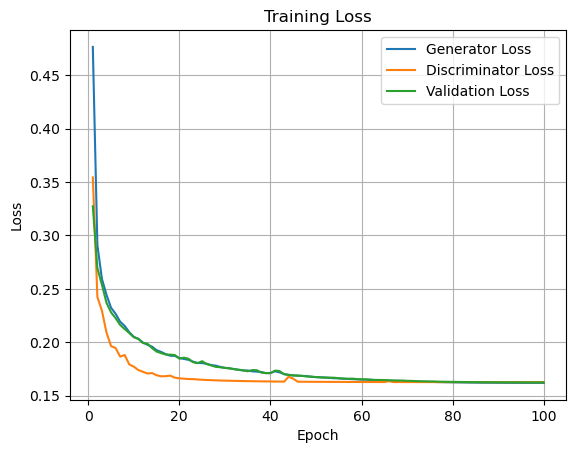

In [15]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss_g"]) + 1)

plt.figure()
plt.plot(epochs, history["train_loss_g"], label="Generator Loss")
plt.plot(epochs, history["train_loss_d"], label="Discriminator Loss")
plt.plot(epochs, history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.grid()

plt.show()

[2026-05-06 03:34:06] Chart config saved → chart_spatial_eval_config.json
[2026-05-06 03:34:12] Chart saved → runs/20260506_013434/srunet_eval_2022-08-01.png


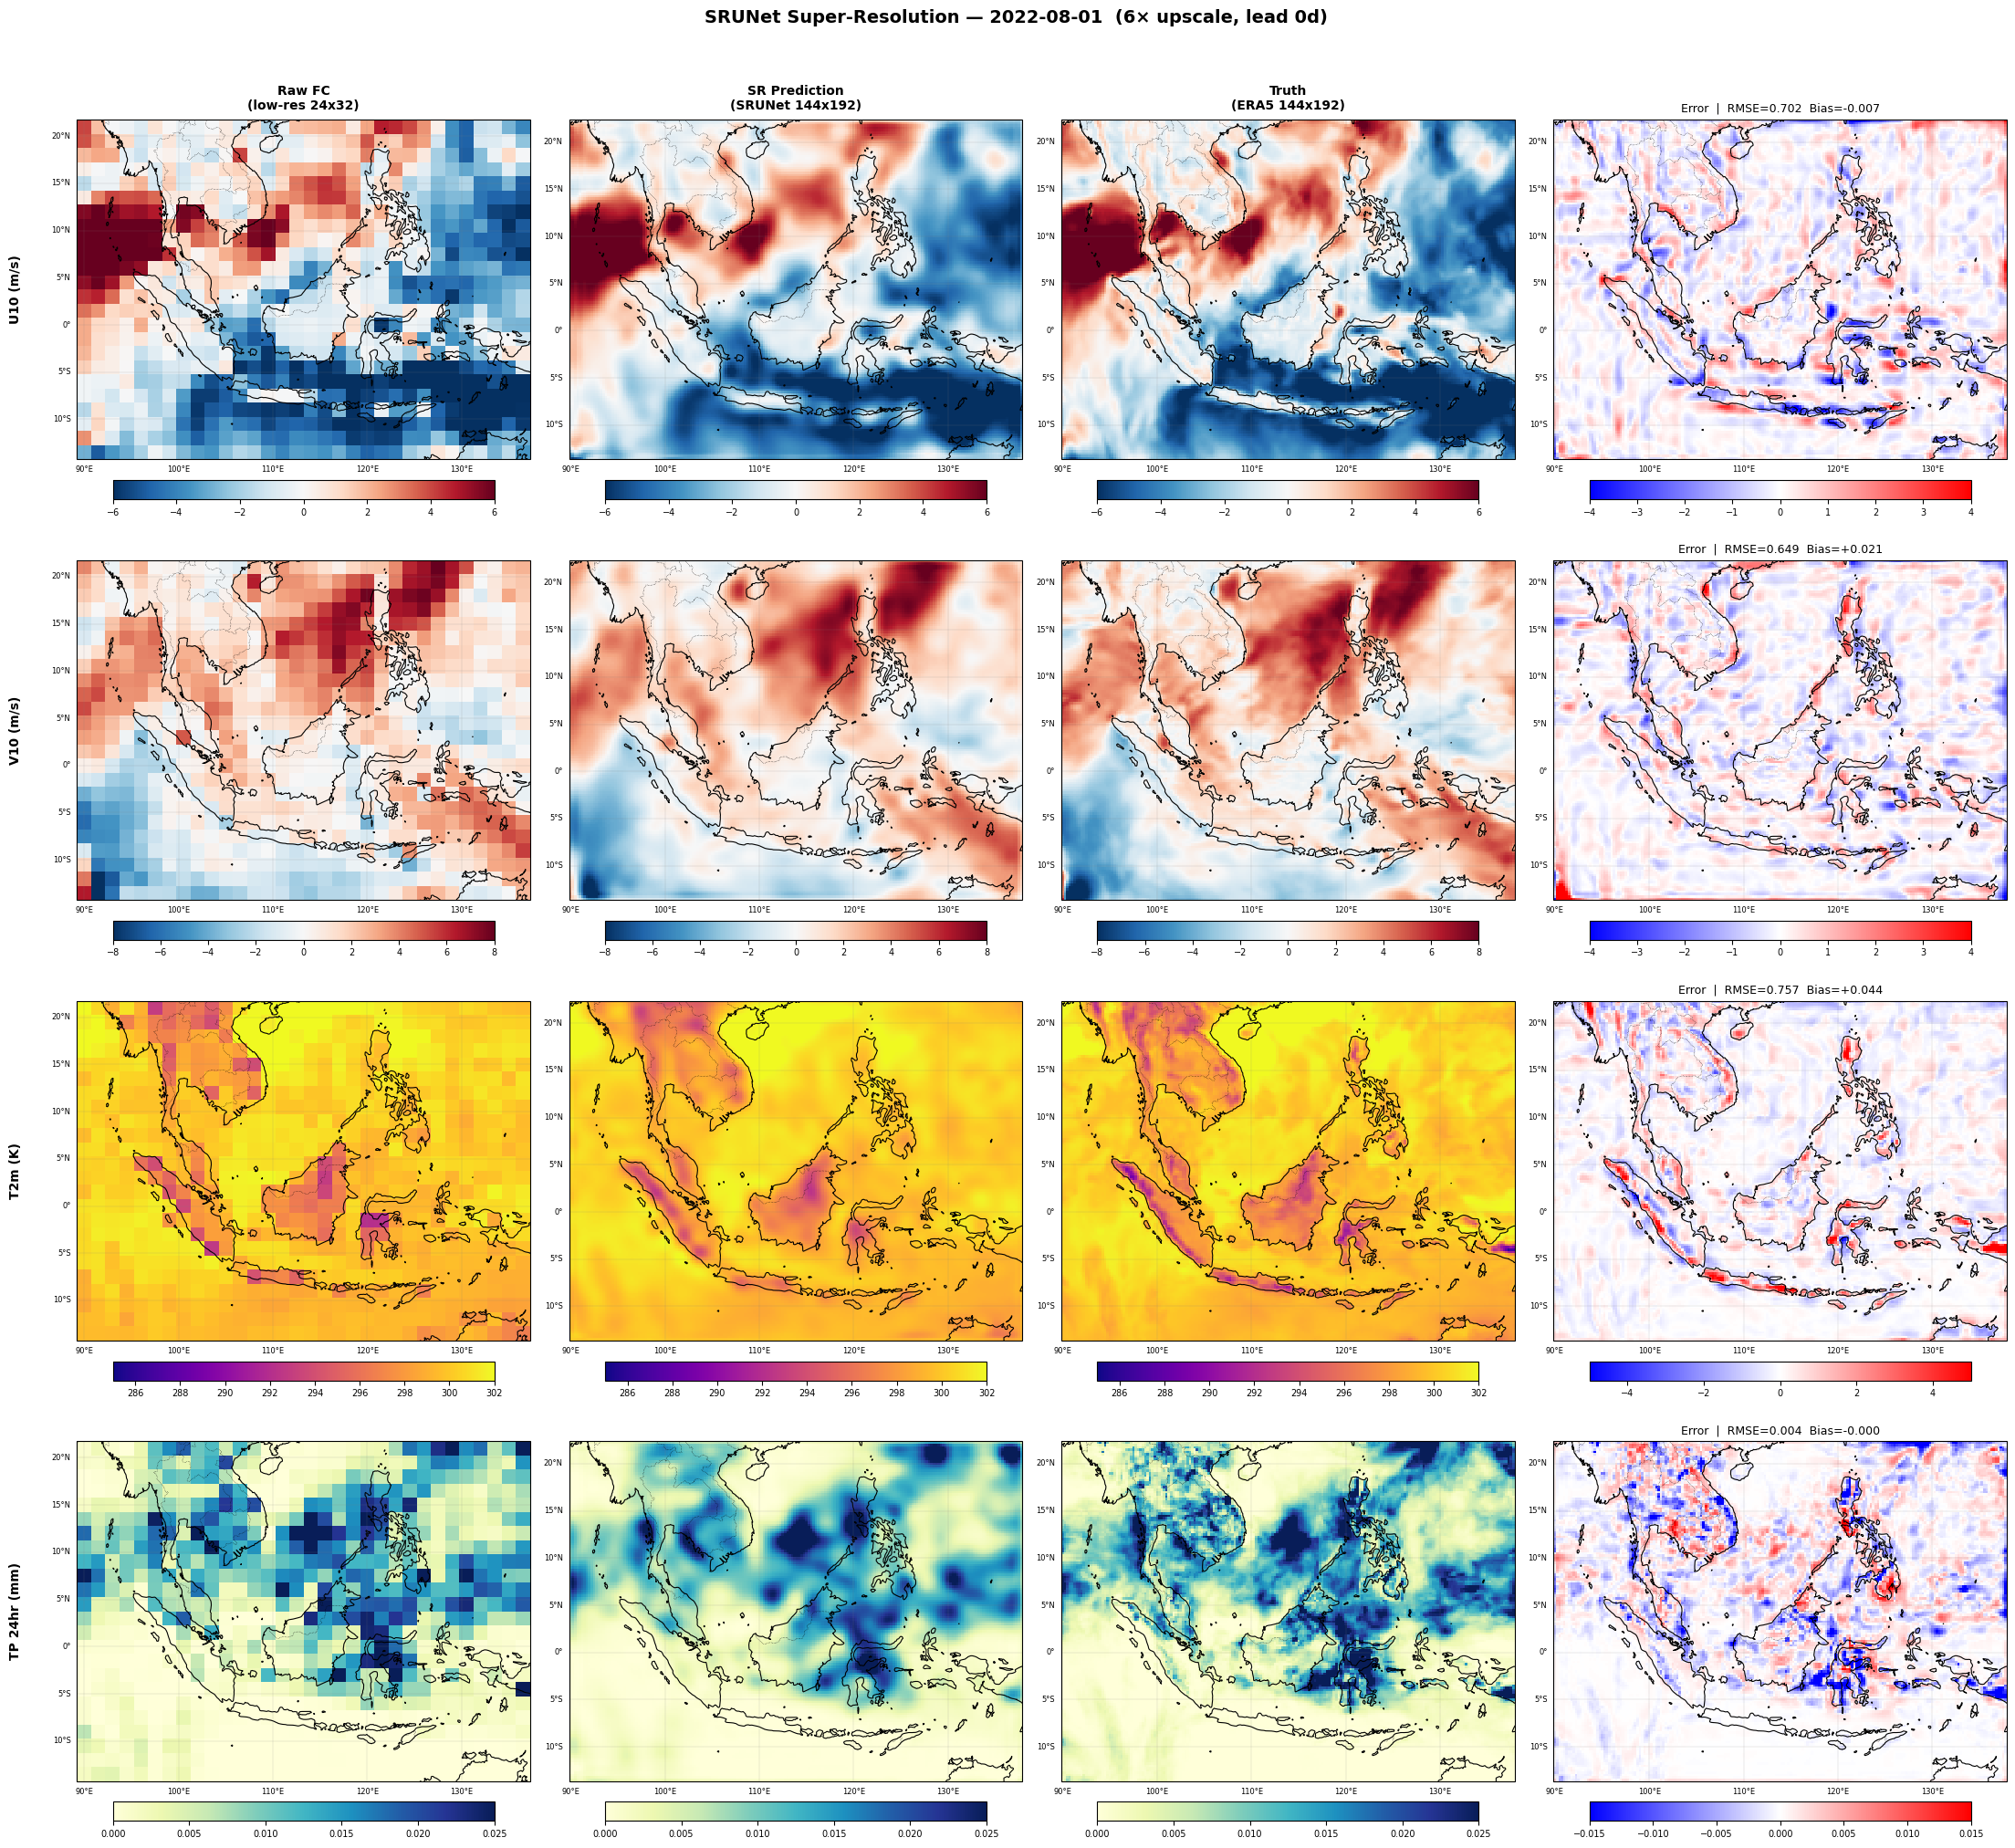

In [16]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import torch
import numpy as np


# Hardcoded color ranges (consistent across notebooks for head-to-head)
#                   U10    V10    T2m       TP
FIELD_VMIN = [      -6,    -8,   285,   0.000]
FIELD_VMAX = [       6,     8,   302,   0.025]
ERROR_LIM  = [       4,     4,     5,   0.015]

# Colormaps — same as regrid notebook
cmaps_field = ["RdBu_r", "RdBu_r", "plasma", "YlGnBu"]

# ── Save chart config ───────────────────────────────────────────────────
_chart2_cfg = {
    'chart'          : 'spatial_eval',
    'target_date'    : str(target_date),
    'lead_days'      : lead_days,
    'figsize'        : [22, 20],
    'FIELD_VMIN'     : FIELD_VMIN,
    'FIELD_VMAX'     : FIELD_VMAX,
    'ERROR_LIM'      : ERROR_LIM,
    'VAR_LABELS_VIZ' : VAR_LABELS_VIZ,
    'cmaps_field'    : cmaps_field,
}
_json.dump(_chart2_cfg, open(os.path.join(RUN_DIR, 'chart_spatial_eval_config.json'), 'w'), indent=2)
_log('Chart config saved → chart_spatial_eval_config.json')



# ==============================
# Find index in test split
# ==============================
test_times = ds_tr_aligned.sel(time=slice(test_start_date, test_end_date)).time.values
idx = np.where(test_times == target_date)[0]
if len(idx) == 0:
    raise ValueError(
        f"{target_date} not found in test set.\n"
        f"Available range: {test_times[0]} → {test_times[-1]}"
    )
idx = idx[0]

# ==============================
# Get sample & predict
# ==============================
device = next(generator.parameters()).device
generator.eval()

X_sample = X_test[[idx]].to(device)
Y_sample = Y_test[[idx]]

with torch.no_grad():
    Y_pred_sample = generator(X_sample).cpu()

# Denormalize — keep T2m in Kelvin (no K→°C) to match regrid notebook
Y_mu  = norm_stats["Y_mean"]
Y_sig = norm_stats["Y_std"]
X_mu  = norm_stats["X_mean"]
X_sig = norm_stats["X_std"]

X_dn   = denormalize(X_sample.cpu(), X_mu, X_sig)[0]   # (4, 24,  32)
Y_true = denormalize(Y_sample,       Y_mu, Y_sig)[0]   # (4, 144, 192)
Y_pred = denormalize(Y_pred_sample,  Y_mu, Y_sig)[0]   # (4, 144, 192)

# ==============================
# Coordinate arrays
# ==============================
lons_lr = ds_fc.longitude.values   # (32,)
lats_lr = ds_fc.latitude.values    # (24,)
lons_hr = ds_tr_aligned.longitude.values  # (192,)
lats_hr = ds_tr_aligned.latitude.values   # (144,)

# ==============================
# Plot: 4 rows × 4 cols  (matching regrid_correction.ipynb layout)
# cols: Raw FC | Prediction (SR) | Truth (ERA5) | Error
# ==============================
proj   = ccrs.PlateCarree()
n_vars = len(VAR_LABELS_VIZ)

col_titles = [
    "Raw FC\n(low-res 24x32)",
    "SR Prediction\n(SRUNet 144x192)",
    "Truth\n(ERA5 144x192)",
    "Error\n(Pred - Truth)",
]

# Colormaps — same as regrid notebook
cmaps_field = ["RdBu_r", "RdBu_r", "plasma", "YlGnBu"]

fig, axes = plt.subplots(
    n_vars, 4,
    figsize=(22, 5 * n_vars),
    subplot_kw={"projection": proj},
)

for v in range(n_vars):
    # PyTorch (C, H, W) → numpy (H, W)
    raw_v  = X_dn[v].numpy()       # (24,  32)
    pred_v = Y_pred[v].numpy()     # (144, 192)
    true_v = Y_true[v].numpy()     # (144, 192)
    err_v  = pred_v - true_v

    cmap_f = cmaps_field[v]

    # Hardcoded ranges
    vmin = FIELD_VMIN[v]
    vmax = FIELD_VMAX[v]
    elim = ERROR_LIM[v]

    panels = [
        (lons_lr, lats_lr, raw_v,  cmap_f, vmin,  vmax),
        (lons_hr, lats_hr, pred_v, cmap_f, vmin,  vmax),
        (lons_hr, lats_hr, true_v, cmap_f, vmin,  vmax),
        (lons_hr, lats_hr, err_v,  "bwr",  -elim,  elim),
    ]

    for col, (lons, lats, data, cmap, lo, hi) in enumerate(panels):
        ax = axes[v, col]

        # Ensure data shape is (n_lats, n_lons) for pcolormesh
        if data.shape != (len(lats), len(lons)):
            data = data.T

        im = ax.pcolormesh(
            lons, lats, data,
            cmap=cmap, vmin=lo, vmax=hi,
            shading="nearest",
            transform=proj,
        )
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS,   linewidth=0.4, linestyle=":")
        ax.add_feature(cfeature.LAND,      facecolor="whitesmoke", zorder=0)
        ax.add_feature(cfeature.OCEAN,     facecolor="lightcyan",  zorder=0)

        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.4)
        gl.top_labels   = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 6}
        gl.ylabel_style = {"size": 6}

        cb = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, fraction=0.046)
        cb.ax.tick_params(labelsize=7)

        if v == 0:
            ax.set_title(col_titles[col], fontsize=10, fontweight="bold", pad=8)
        if col == 0:
            ax.text(-0.15, 0.5, VAR_LABELS_VIZ[v], transform=ax.transAxes,
                    fontsize=10, fontweight="bold", va="center", rotation=90)

    # RMSE + bias on error panel
    rmse = np.sqrt(np.mean(err_v ** 2))
    bias = np.mean(err_v)
    axes[v, 3].set_title(
        f"Error  |  RMSE={rmse:.3f}  Bias={bias:+.3f}",
        fontsize=9, pad=6,
    )

fig.suptitle(
    f"SRUNet Super-Resolution — {str(target_date)[:10]}  (6× upscale, lead {lead_days}d)",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()
save_fig(fig, f"srunet_eval_{str(target_date)[:10]}.png", dpi=150)
plt.show()

In [17]:
# ==========================================
# Helpers: compute_metrics / print_metrics
# ==========================================

def compute_metrics(preds_norm, targets_norm, Y_mu, Y_sig):
    """
    Denormalize both tensors, then compute per-variable
    RMSE, MAE, Bias, and Corr over the full (N, C, H, W) batch.
    Returns: dict  { VAR_LABELS[i]: {RMSE, MAE, Bias, Corr} }
    """
    p_dn = denormalize(preds_norm.clone(),   Y_mu, Y_sig).numpy()  # (N,C,H,W)
    t_dn = denormalize(targets_norm.clone(), Y_mu, Y_sig).numpy()

    results = {}
    for vi, label in enumerate(VAR_LABELS):
        p = p_dn[:, vi]; t = t_dn[:, vi]
        rmse = float(np.sqrt(np.mean((p - t) ** 2)))
        mae  = float(np.mean(np.abs(p - t)))
        bias = float(np.mean(p - t))
        pd_  = p - p.mean(); td_ = t - t.mean()
        with np.errstate(divide="ignore", invalid="ignore"):
            corr = float(
                np.sum(pd_ * td_) /
                (np.sqrt(np.sum(pd_**2) * np.sum(td_**2)) + 1e-12)
            )
        results[label] = {"RMSE": rmse, "MAE": mae, "Bias": bias, "Corr": corr}
    return results


def print_metrics(metrics: dict, prefix: str = "Metrics"):
    """Pretty-print a compute_metrics() result dict and log to runtime.log."""
    hdr  = f"\n{prefix}"
    line = "-" * 72
    print(hdr); print(line)
    _log(hdr)
    for label, m in metrics.items():
        r, a, b, c = m["RMSE"], m["MAE"], m["Bias"], m["Corr"]
        msg = (f"  {label:<22}  RMSE={r:8.4f}  MAE={a:8.4f}  "
               f"Bias={b:+8.4f}  Corr={c:6.4f}")
        print(msg); _log(msg)
    print(line)


# ==========================================
# evaluate_test — loads best checkpoint,
# runs inference on test_loader, returns
# metrics + raw prediction tensors
# ==========================================

def evaluate_test(model, test_loader, norm_stats,
                  device="cuda" if torch.cuda.is_available() else "cpu"):
    ckpt_path = os.path.join(RUN_DIR, "best_model.pt")
    _log(f"Loading checkpoint: {ckpt_path}")
    checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["generator"])
    model = model.to(device)
    model.eval()

    Y_mu  = norm_stats["Y_mean"]
    Y_sig = norm_stats["Y_std"]

    all_preds   = []
    all_targets = []

    with torch.no_grad():
        for X_batch, Y_batch in test_loader:
            pred = model(X_batch.to(device))
            all_preds.append(pred.cpu())
            all_targets.append(Y_batch)

    all_preds   = torch.cat(all_preds,   dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    metrics = compute_metrics(all_preds, all_targets, Y_mu, Y_sig)
    print_metrics(metrics, prefix="🧪 Test Set Metrics")
    return metrics, all_preds, all_targets


test_metrics, test_preds, test_targets = evaluate_test(
    generator, test_loader, norm_stats
)

[2026-05-06 03:34:16] Loading checkpoint: runs/20260506_013434/best_model.pt

🧪 Test Set Metrics
------------------------------------------------------------------------
[2026-05-06 03:34:18] 
🧪 Test Set Metrics
  U10 (m/s)               RMSE=  0.8062  MAE=  0.5164  Bias= -0.0071  Corr=0.9794
[2026-05-06 03:34:18]   U10 (m/s)               RMSE=  0.8062  MAE=  0.5164  Bias= -0.0071  Corr=0.9794
  V10 (m/s)               RMSE=  0.7534  MAE=  0.4921  Bias= -0.0034  Corr=0.9739
[2026-05-06 03:34:18]   V10 (m/s)               RMSE=  0.7534  MAE=  0.4921  Bias= -0.0034  Corr=0.9739
  T2m (K)                 RMSE=  0.8651  MAE=  0.4684  Bias= +0.0582  Corr=0.9156
[2026-05-06 03:34:18]   T2m (K)                 RMSE=  0.8651  MAE=  0.4684  Bias= +0.0582  Corr=0.9156
  TP 24hr (mm)            RMSE=  0.0054  MAE=  0.0023  Bias= -0.0005  Corr=0.8955
[2026-05-06 03:34:18]   TP 24hr (mm)            RMSE=  0.0054  MAE=  0.0023  Bias= -0.0005  Corr=0.8955
--------------------------------------------

In [18]:
# ==============================
# Aggregate test-set evaluation
# (Corrected Spatio-Temporal Metrics)
# ==============================
import numpy as np
import xarray as xr

Y_mu  = norm_stats["Y_mean"]
Y_sig = norm_stats["Y_std"]

# Denormalize model predictions/targets (physical space)
y_pred_phys = denormalize(test_preds.clone(), Y_mu, Y_sig).numpy()
y_true_phys = denormalize(test_targets.clone(), Y_mu, Y_sig).numpy()

# Build baseline exactly like QM notebook:
# low-res ds_fc test slice -> (fill NaN) -> linear interpolation to truth test grid
fc_test_lowres = ds_fc.sel(time=slice(test_start_date, test_end_date)).copy(deep=True)
tr_test_ds = ds_tr_aligned.sel(time=slice(test_start_date, test_end_date))

# Match QM NaN handling before baseline interpolation
for v_name in VARS:
    if np.isnan(fc_test_lowres[v_name].values).any():
        fill_val = float(np.nanmean(fc_test_lowres[v_name].values))
        fc_test_lowres[v_name] = fc_test_lowres[v_name].fillna(fill_val)

# Compute baseline RMSE on full HR grid (time-aligned only, not lat/lon inner join)
baseline_rmse_by_var = {}
for v_name in VARS:
    low_da = fc_test_lowres[v_name].transpose('time', 'latitude', 'longitude')
    truth_da_xr = tr_test_ds[v_name].transpose('time', 'latitude', 'longitude')

    # Align only along time; keep each dataset's native spatial grids
    common_time = np.intersect1d(low_da.time.values, truth_da_xr.time.values)
    low_da = low_da.sel(time=common_time)
    truth_da_xr = truth_da_xr.sel(time=common_time)

    # Baseline: bilinear upsample LR -> HR truth grid
    base_da = low_da.interp(
        latitude=truth_da_xr.latitude,
        longitude=truth_da_xr.longitude,
        method='linear',
    )

    base_v_xr = base_da.values
    true_v_xr = truth_da_xr.values
    rmse_base_grid = np.sqrt(np.mean((base_v_xr - true_v_xr) ** 2, axis=0))
    baseline_rmse_by_var[v_name] = float(np.nanmean(rmse_base_grid))

print("\n" + "=" * 100)
print(f"{'Variable':<18} | {'RMSE':>8} | {'MAE':>8} | {'Bias':>8} | {'Corr':>8} | {'Baseline RMSE':>14} | {'Skill':>8}")
print("=" * 100)

BASELINE_EPS = 1e-8

for v_idx, v_name in enumerate(VARS):
    pred_v = y_pred_phys[:, v_idx, :, :]
    true_v = y_true_phys[:, v_idx, :, :]

    n = min(pred_v.shape[0], true_v.shape[0])
    pred_v = pred_v[:n]
    true_v = true_v[:n]

    rmse_grid = np.sqrt(np.mean((pred_v - true_v) ** 2, axis=0))
    mae_grid = np.mean(np.abs(pred_v - true_v), axis=0)
    bias_grid = np.mean(pred_v - true_v, axis=0)

    pred_diff = pred_v - np.mean(pred_v, axis=0)
    true_diff = true_v - np.mean(true_v, axis=0)
    cov = np.sum(pred_diff * true_diff, axis=0)
    var_pred = np.sum(pred_diff ** 2, axis=0)
    var_true = np.sum(true_diff ** 2, axis=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        corr_grid = cov / np.sqrt(var_pred * var_true)

    rmse = float(np.nanmean(rmse_grid))
    mae = float(np.nanmean(mae_grid))
    bias = float(np.nanmean(bias_grid))
    corr = float(np.nanmean(corr_grid))

    rmse_base = baseline_rmse_by_var[v_name]
    skill = 1.0 - (rmse / rmse_base) if rmse_base > BASELINE_EPS else 0.0

    label = VAR_LABELS[v_idx]
    print(f"{label:<18} | {rmse:8.4f} | {mae:8.4f} | {bias:+8.4f} | {corr:8.4f} | {rmse_base:14.4f} | {skill:+8.4f}")

print("=" * 100)
print("\nSkill > 0 means SRUNet improves over bilinear interpolation baseline.")

# ── Save final test metrics to CSV ──────────────────────────────────────
import csv as _csv

_metrics_rows = []
for v_idx, v_name in enumerate(VARS):
    _pv = y_pred_phys[:, v_idx, :, :]
    _tv = y_true_phys[:, v_idx, :, :]
    _n = min(_pv.shape[0], _tv.shape[0])
    _pv = _pv[:_n]
    _tv = _tv[:_n]

    _rmse_g = np.sqrt(np.mean((_pv - _tv) ** 2, axis=0))
    _mae_g = np.mean(np.abs(_pv - _tv), axis=0)
    _bias_g = np.mean(_pv - _tv, axis=0)
    _pd = _pv - np.mean(_pv, axis=0)
    _td = _tv - np.mean(_tv, axis=0)
    _cov = np.sum(_pd * _td, axis=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        _corr_g = _cov / np.sqrt(np.sum(_pd**2, axis=0) * np.sum(_td**2, axis=0))

    _rmse = float(np.nanmean(_rmse_g))
    _rbase = baseline_rmse_by_var[v_name]
    _metrics_rows.append({
        'variable': v_name,
        'label': VAR_LABELS[v_idx],
        'RMSE': _rmse,
        'MAE': float(np.nanmean(_mae_g)),
        'Bias': float(np.nanmean(_bias_g)),
        'Corr': float(np.nanmean(_corr_g)),
        'Baseline_RMSE': _rbase,
        'Skill': float(1.0 - (_rmse / _rbase)) if _rbase > BASELINE_EPS else 0.0,
    })

_csv_path = os.path.join(RUN_DIR, 'metrics.csv')
_fields = ['variable', 'label', 'RMSE', 'MAE', 'Bias', 'Corr', 'Baseline_RMSE', 'Skill']
with open(_csv_path, 'w', newline='') as _f:
    _w = _csv.DictWriter(_f, fieldnames=_fields)
    _w.writeheader()
    _w.writerows(_metrics_rows)
_log(f'Metrics saved → {_csv_path}')

# ── Log run completion ───────────────────────────────────────────────────
_total = _dt.datetime.now() - _run_start
_log(f'=== Run finished  total_elapsed={str(_total).split(".")[0]} ===')
_log(f'All outputs in: {RUN_DIR}')
print(f'\n✅ All outputs saved to: {RUN_DIR}')


Variable           |     RMSE |      MAE |     Bias |     Corr |  Baseline RMSE |    Skill
U10 (m/s)          |   0.6825 |   0.5164 |  -0.0071 |   0.9392 |         0.6595 |  -0.0350
V10 (m/s)          |   0.6528 |   0.4921 |  -0.0034 |   0.9320 |         0.6327 |  -0.0316
T2m (K)            |   0.5728 |   0.4684 |  +0.0582 |   0.9279 |         0.5610 |  -0.0209
TP 24hr (mm)       |   0.0046 |   0.0023 |  -0.0005 |   0.9020 |         0.0046 |  -0.0076

Skill > 0 means SRUNet improves over bilinear interpolation baseline.
[2026-05-06 03:34:21] Metrics saved → runs/20260506_013434/metrics.csv
[2026-05-06 03:34:21] === Run finished  total_elapsed=1:59:47 ===
[2026-05-06 03:34:21] All outputs in: runs/20260506_013434

✅ All outputs saved to: runs/20260506_013434


In [19]:
# After training: ensure best_model.pt contains normalization stats for inference/evaluation
save_path = os.path.join(RUN_DIR, 'best_model.pt')
if os.path.exists(save_path):
    ckpt = torch.load(save_path, map_location='cpu')
    changed = False
    # Add missing per-tensor stats if present in `norm_stats`
    for k in ('X_mean','X_std','Y_mean','Y_std'):
        if k not in ckpt:
            v = norm_stats.get(k) if isinstance(norm_stats, dict) else None
            if v is not None:
                # ensure tensor format stored in checkpoint
                if torch.is_tensor(v):
                    ckpt[k] = v.clone()
                else:
                    ckpt[k] = torch.tensor(v, dtype=torch.float32)
                changed = True
    # Keep a copy of the full norm_stats dict for backwards compatibility
    if 'norm_stats' not in ckpt:
        ckpt['norm_stats'] = norm_stats
        changed = True
    if changed:
        torch.save(ckpt, save_path)
        print(f"Appended norm_stats to checkpoint -> {save_path}")
    else:
        print("Checkpoint already contains normalization stats.")
else:
    print(f"No checkpoint found at {save_path} — nothing to append.")

Appended norm_stats to checkpoint -> runs/20260506_013434/best_model.pt
